In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

### Callbacks

In [2]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    start_from_epoch=10
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6
)

# Dataset Preprocessing

In [3]:
dataset = keras.utils.image_dataset_from_directory(
    "data/fog-or-smog-detection-dataset",
    image_size=(128, 128),
    batch_size=32,
    label_mode="binary"
)

Found 2335 files belonging to 2 classes.


In [4]:
dataset_size = len(dataset)

train_size = dataset_size * 0.75
val_size = dataset_size * 0.10
test_size = dataset_size * 0.15

train_ds = dataset.take(int(train_size)).prefetch(tf.data.AUTOTUNE)
val_ds = dataset.skip(int(train_size)).take(int(val_size)).prefetch(tf.data.AUTOTUNE)
test_ds = dataset.skip(int(train_size) + int(val_size)).take(int(test_size))

In [5]:
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomFlip("vertical"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
    ]
)

# Model Training

In [6]:
base = keras.applications.MobileNetV2(
    input_shape=(128, 128, 3),
    include_top=False,
    weights='imagenet'
)
base.trainable = False

In [7]:
model = keras.Sequential([
    layers.Lambda(keras.applications.mobilenet_v2.preprocess_input),
    data_augmentation,
    base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(1, activation='sigmoid')
])

In [8]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [9]:
history = model.fit(train_ds, validation_data=val_ds, epochs=30, callbacks=[early_stopping, reduce_lr])

Epoch 1/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 16s 271ms/step - accuracy: 0.8235 - loss: 0.3742 - val_accuracy: 0.7812 - val_loss: 0.4579 - learning_rate: 0.0010
Epoch 2/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 18s 324ms/step - accuracy: 0.9485 - loss: 0.1465 - val_accuracy: 0.8527 - val_loss: 0.3626 - learning_rate: 0.0010
Epoch 3/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 21s 388ms/step - accuracy: 0.9676 - loss: 0.1062 - val_accuracy: 0.8839 - val_loss: 0.2670 - learning_rate: 0.0010
Epoch 4/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 23s 412ms/step - accuracy: 0.9682 - loss: 0.0905 - val_accuracy: 0.9196 - val_loss: 0.1906 - learning_rate: 0.0010
Epoch 5/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 22s 399ms/step - accuracy: 0.9734 - loss: 0.0822 - val_accuracy: 0.9420 - val_loss: 0.1850 - learning_rate: 0.0010
Epoch 6/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 17s 312ms/step - accuracy: 0.9797 - loss: 0.0689 - val_accuracy: 0.9464 - val_loss: 0.1499 - learning_rate: 0.0010
Epoch 7/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 17s 321ms/step - accuracy: 0.9763 - loss: 0.

# Model Evaluation

In [10]:
y_true = []
y_pred = []

In [11]:
for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_pred.extend((preds > 0.5).astype(int).flatten())
    y_true.extend(labels.numpy().astype(int).flatten())

2026-05-22 23:21:12.227281: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


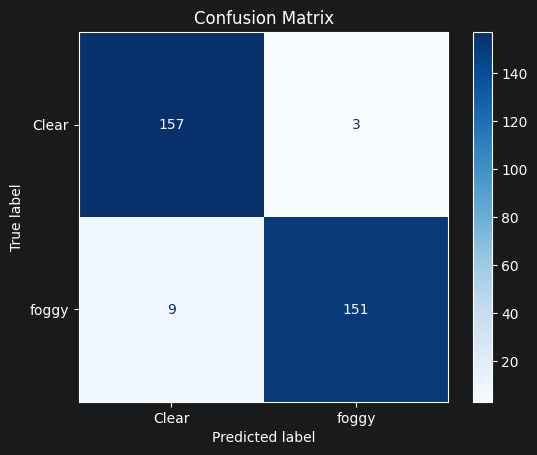

In [12]:
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=dataset.class_names)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

# Saving

In [13]:
model.save("models/mobilenetv2.keras")